----

# Análisis de Datos de Taxis en Chicago: Impacto del Clima en la Duración de Viajes

## Introducción

Como analista de datos, este proyecto demuestra mi experiencia en el uso de herramientas especializadas para extraer insights valiosos de grandes conjuntos de datos. A través de un análisis exhaustivo de datos de taxis en Chicago, investigo cómo las condiciones climáticas afectan los patrones de transporte urbano.

### Objetivo Principal
Determinar si existe una diferencia estadísticamente significativa en la duración promedio de los viajes durante días lluviosos comparado con días de buen clima.

### Herramientas y Metodología
- **Python** para procesamiento y análisis de datos
- **Pandas** para manipulación de datasets
- **Matplotlib/Seaborn** para visualización de datos
- **SciPy** para pruebas estadísticas
- **Análisis exploratorio** y **pruebas de hipótesis**

In [1]:
import pandas as pd

companies = pd.read_csv("/datasets/project_sql_result_01.csv")

companies.info()
print(companies.head(10))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB
                        company_name  trips_amount
0                          Flash Cab         19558
1          Taxi Affiliation Services         11422
2                  Medallion Leasing         10367
3                         Yellow Cab          9888
4    Taxi Affiliation Service Yellow          9299
5          Chicago Carriage Cab Corp          9181
6                       City Service          8448
7                           Sun Taxi          7701
8          Star North Management LLC          7455
9  Blue Ribbon Taxi Association Inc.          5953


In [2]:
trips = pd.read_csv("/datasets/project_sql_result_04.csv")

trips.info()
print(trips.head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     object 
 1   average_trips          94 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.6+ KB
  dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Streeterville    6664.666667
3             West Loop    5163.666667
4                O'Hare    2546.900000
5             Lake View    2420.966667
6            Grant Park    2068.533333
7         Museum Campus    1510.000000
8            Gold Coast    1364.233333
9    Sheffield & DePaul    1259.766667


Para ambos archivos encontramos que los tipos de datos son adecuados para trabajar con ellos, para "Companies" tiene datos tipo object para los nombres de las compañias y tipo int64(enteros) para la cantidad de viajes. Por otro lado para "trips" los lugares donde se dejan los pasajeros son tipo object y el promedio de los viajes es tipo float (decimal), lo cual es esperado al ser un promedio. 

In [3]:

top_10_barrios = trips.sort_values('average_trips', ascending=False).head(10)
print(top_10_barrios)


  dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Streeterville    6664.666667
3             West Loop    5163.666667
4                O'Hare    2546.900000
5             Lake View    2420.966667
6            Grant Park    2068.533333
7         Museum Campus    1510.000000
8            Gold Coast    1364.233333
9    Sheffield & DePaul    1259.766667


Se evidencia que el barrio donde mas se terminan viajes es "Loop" con una diferencia de casi 1200 viajes en promedio. 

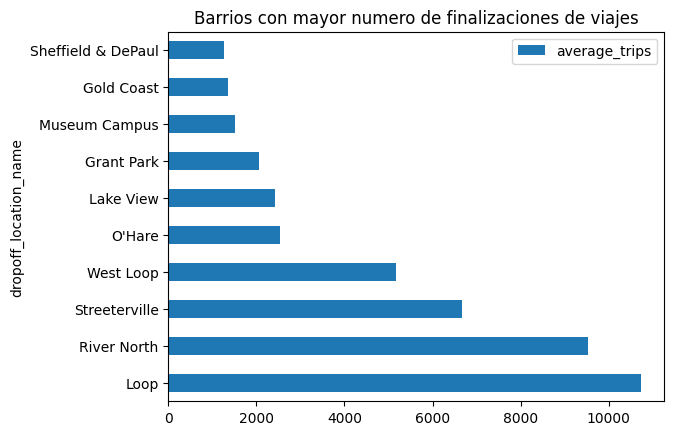

In [4]:

from matplotlib import pyplot as plt

top_10_barrios.plot(x="dropoff_location_name", y="average_trips", kind="barh", title="Barrios con mayor numero de finalizaciones de viajes")
plt.show()


In [23]:
top_10_companies = companies.sort_values('trips_amount', ascending=False).head(10)
print(top_10_companies)


                        company_name  trips_amount
0                          Flash Cab         19558
1          Taxi Affiliation Services         11422
2                  Medallion Leasing         10367
3                         Yellow Cab          9888
4    Taxi Affiliation Service Yellow          9299
5          Chicago Carriage Cab Corp          9181
6                       City Service          8448
7                           Sun Taxi          7701
8          Star North Management LLC          7455
9  Blue Ribbon Taxi Association Inc.          5953


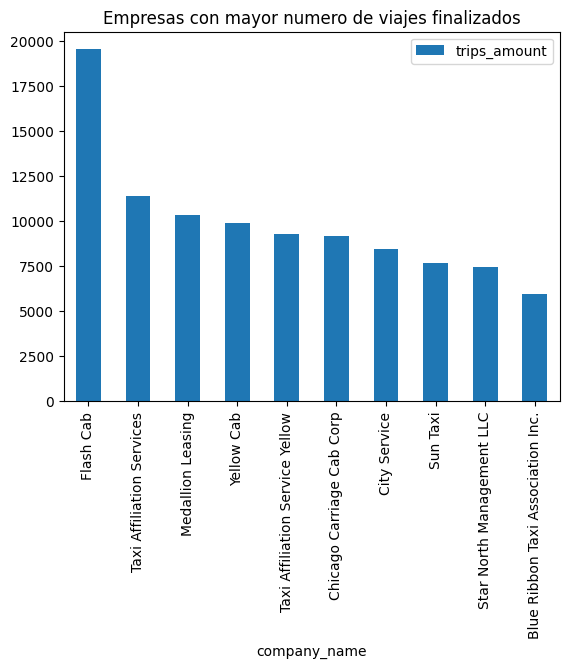

In [26]:
from matplotlib import pyplot as plt

top_10_companies.plot(x="company_name", y="trips_amount", kind="bar", title="Empresas con mayor numero de viajes finalizados")
plt.show()


CONCLUSIONES:
Al revisar estas graficas podemos evidenciar que la empresa con mayor numero promedio de viajes terminados en noviembre de 2017 fue "Loop", notando que la empresa "West Loop" dobla en cantidad promedio los viajes finalizados. 

Por otro lado evidenciamos que la compañia de taxis que mas viajes realizó fue "Flash Cab" seguida de "Taxi Affiliation Services" y "Medallion Leasing". Considerando la conclusion anteior podriamos afirmar que estas tres empresas son las que mas viajes realizaron al barrio "Loop".

PRUEBA DE HIPOTESIS

Para realizar la prueba de hipotesis a continuacion realizamos una revision de los datos, revisando los tipos de datos que contiene el DataFrame y si es necesario hacer algun cambio. Asi mismo identificar y organizar lo datos para probar lo siguiente:

Hipótesis nula (H0): "No hay diferencia" - Los viajes duran lo mismo con lluvia o sin lluvia los sábados
Hipótesis alternativa (H1): "Sí hay diferencia" - Los viajes duran diferente con lluvia vs sin lluvia los sábados.


In [7]:
import pandas as pd

trips_loop_aero = pd.read_csv("/datasets/project_sql_result_07.csv")

trips_loop_aero.info()
print(" ")
print(trips_loop_aero.head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   start_ts            1068 non-null   object 
 1   weather_conditions  1068 non-null   object 
 2   duration_seconds    1068 non-null   float64
dtypes: float64(1), object(2)
memory usage: 25.2+ KB
 
              start_ts weather_conditions  duration_seconds
0  2017-11-25 16:00:00               Good            2410.0
1  2017-11-25 14:00:00               Good            1920.0
2  2017-11-25 12:00:00               Good            1543.0
3  2017-11-04 10:00:00               Good            2512.0
4  2017-11-11 07:00:00               Good            1440.0
5  2017-11-11 04:00:00               Good            1320.0
6  2017-11-04 16:00:00                Bad            2969.0
7  2017-11-18 11:00:00               Good            2280.0
8  2017-11-11 14:00:00               Good            2

In [15]:
sabados = trips_loop_aero.copy()
print(f"Número total de viajes en sábado: {len(sabados)}")

Número total de viajes en sábado: 1068


In [16]:
# Grupo 1: Sábados con buen clima (Good)
sabados_buen_clima = sabados[sabados['weather_conditions'] == 'Good']

# Grupo 2: Sábados con mal clima/lluvia (Bad)  
sabados_mal_clima = sabados[sabados['weather_conditions'] == 'Bad']

print(f"Sábados con buen clima: {len(sabados_buen_clima)}")
print(f"Sábados con mal clima: {len(sabados_mal_clima)}")

Sábados con buen clima: 888
Sábados con mal clima: 180


In [17]:
# Calcular duraciones promedio para cada grupo
duracion_promedio_buen_clima = sabados_buen_clima['duration_seconds'].mean()
duracion_promedio_mal_clima = sabados_mal_clima['duration_seconds'].mean()

print(f"Duración promedio en sábados con buen clima: {duracion_promedio_buen_clima:.2f} segundos")
print(f"Duración promedio en sábados con mal clima: {duracion_promedio_mal_clima:.2f} segundos")

# Calcular la diferencia
diferencia = duracion_promedio_mal_clima - duracion_promedio_buen_clima
print(f"Diferencia: {diferencia:.2f} segundos")

Duración promedio en sábados con buen clima: 1999.68 segundos
Duración promedio en sábados con mal clima: 2427.21 segundos
Diferencia: 427.53 segundos


In [19]:

from scipy import stats

alpha = 0.05

ho_test = stats.ttest_ind(
    sabados_buen_clima['duration_seconds'], 
    sabados_mal_clima['duration_seconds']
)

print('valor p: ', ho_test.pvalue)

if (ho_test.pvalue < alpha):
    print('Rechazamos la hipótesis nula')
else:
    print("No podemos rechazar la hipótesis nula")


valor p:  6.517970327099473e-12
Rechazamos la hipótesis nula


## Conclusiones y Hallazgos Principales

### Resultado Principal
El análisis estadístico confirma que **existe una diferencia significativa** en la duración de los viajes de taxi los sábados según las condiciones climáticas:

- **Días de buen clima**: 1,999.68 segundos promedio (~33.3 minutos)
- **Días lluviosos**: 2,427.21 segundos promedio (~40.5 minutos)
- **Diferencia**: 427.53 segundos adicionales (~7.1 minutos más en días lluviosos)

### Significancia Estadística
- **p-value**: 6.52e-12 (altamente significativo)
- **Nivel de confianza**: 95% (α = 0.05)
- **Conclusión**: Rechazamos la hipótesis nula con alta confianza

### Implicaciones Prácticas
Este hallazgo tiene importantes implicaciones para:
- **Planificación de rutas** en días de mal clima
- **Estimación de tiempos** para usuarios
- **Estrategias de precios** dinámicos
- **Gestión de flota** durante condiciones adversas
